# Karak tutorial 2: loading the publication sample (NWA 4587)

Tutorial 1 walked the `load_elements` stage on a synthetic scene. This notebook runs the same stages on the real thing: the TIMA export of NWA 4587 (section NAW 4587-2, scan S3858) that the paper uses.

The export is 21 PNGs at 13050×7980 pixels, about 300 MB per file: 19 element maps, a duplicate low-energy iron map (`Fe-L`), and a grayscale SEM/BSE image. All loading parameters below come from `karak_replication/replication_config.yaml`, the config replicated from the paper baseline run. Conveniently, every one of those parameters is the stage default, because karak's defaults were set from this dataset: jet colormap, legacy TIMA filename heuristic, 100 px header trim, downsample factor 2, `Fe-L` excluded, `SEM` as the BSE channel.

The full load at the end needs about 2 GB of RAM and a few minutes of runtime.

In [1]:
import logging
from pathlib import Path

import imageio.v2 as imageio
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from karak.io.loaders import invert_colormap

# These are trusted instrument exports at 104 Mpx each; PIL's
# decompression-bomb guard trips at 89 Mpx, so raise the limit.
Image.MAX_IMAGE_PIXELS = None

logging.basicConfig(level=logging.INFO, format="%(message)s")
plt.rcParams["figure.dpi"] = 100

DATA_DIR = Path("/home/brendon/Dropbox/Projects/izawa/NWA4587_LPSC26/data")
assert DATA_DIR.exists(), "publication data directory not found"

## Step 1: file discovery

The filenames follow the TIMA convention `{prefix}-{sampleid}-{element}.png`, here `NAW 4587-2_S3858-{element}.png`. The legacy heuristic splits the stem on `-` and joins everything from the third part on, so `NAW 4587-2_S3858-Fe-K` parses to `Fe-K` rather than losing the line suffix.

Two parsed names get special treatment during loading:

- `SEM` is the configured BSE channel, stored as grayscale, not an element.
- `Fe-L` is on the exclude list. It is the low-energy iron line and duplicates the `Fe-K` signal, so the paper config drops it.

In [2]:
files = sorted(DATA_DIR.glob("*.png"))
print(f"{len(files)} PNG files\n")
for path in files:
    element = "-".join(path.stem.split("-")[2:])  # the loader's legacy rule
    if element == "SEM":
        kind = "BSE channel"
    elif element == "Fe-L":
        kind = "element map (excluded)"
    else:
        kind = "element map"
    size_mb = path.stat().st_size / 1e6
    print(f"{path.name:32s} -> {element:5s} ({kind}, {size_mb:.0f} MB)")

21 PNG files

NAW 4587-2_S3858-Al.png          -> Al    (element map, 36 MB)
NAW 4587-2_S3858-Ba.png          -> Ba    (element map, 33 MB)
NAW 4587-2_S3858-Ca.png          -> Ca    (element map, 48 MB)
NAW 4587-2_S3858-Cl.png          -> Cl    (element map, 44 MB)
NAW 4587-2_S3858-Cr.png          -> Cr    (element map, 32 MB)
NAW 4587-2_S3858-F.png           -> F     (element map, 34 MB)
NAW 4587-2_S3858-Fe-K.png        -> Fe-K  (element map, 41 MB)
NAW 4587-2_S3858-Fe-L.png        -> Fe-L  (element map (excluded), 32 MB)
NAW 4587-2_S3858-K.png           -> K     (element map, 39 MB)
NAW 4587-2_S3858-Mg.png          -> Mg    (element map, 35 MB)
NAW 4587-2_S3858-Mn.png          -> Mn    (element map, 43 MB)
NAW 4587-2_S3858-Na.png          -> Na    (element map, 42 MB)
NAW 4587-2_S3858-O.png           -> O     (element map, 42 MB)
NAW 4587-2_S3858-P.png           -> P     (element map, 27 MB)
NAW 4587-2_S3858-S.png           -> S     (element map, 44 MB)
NAW 4587-2_S3858-SEM.png      

## A first look at the raw exports

Six representative channels, displayed at 1/16 resolution to keep the notebook light. The element maps are jet-colored; the SEM image is grayscale.

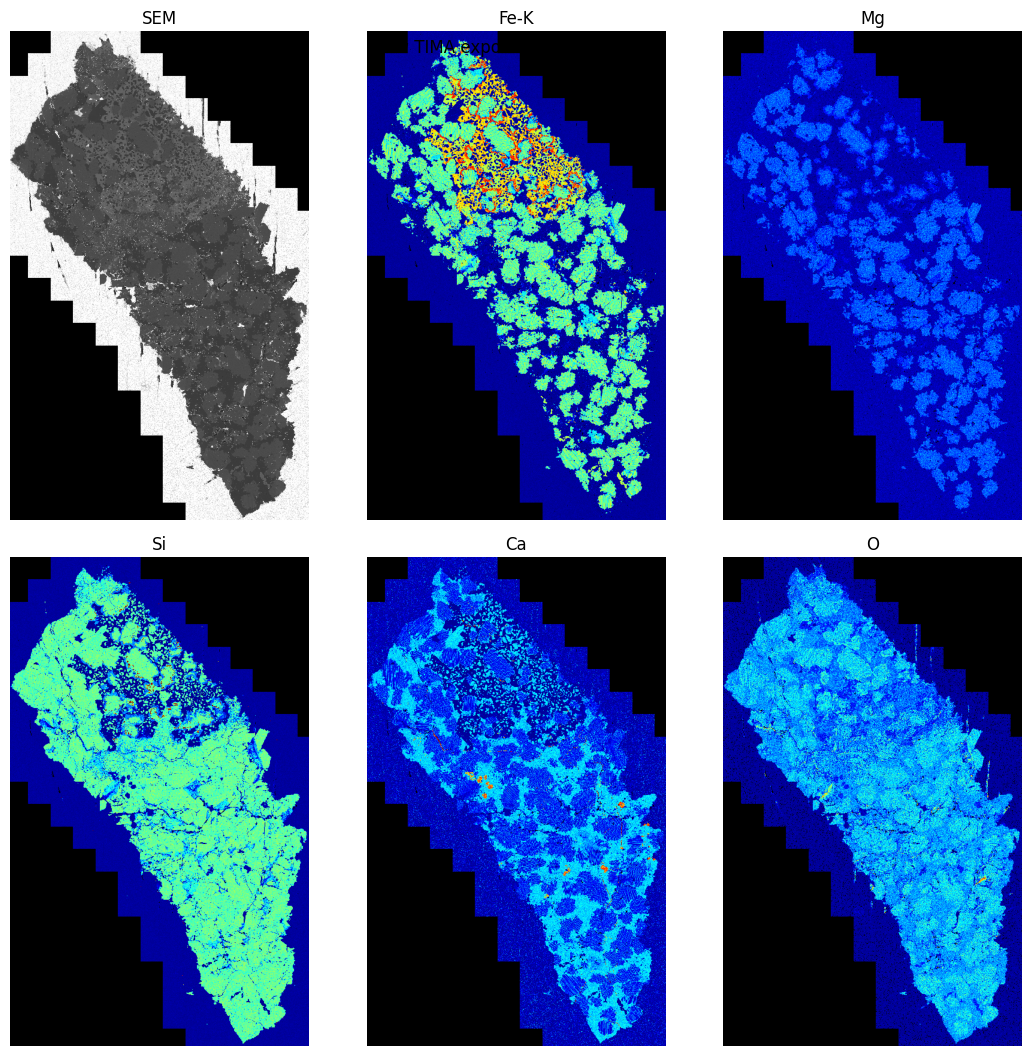

In [3]:
preview_channels = ["SEM", "Fe-K", "Mg", "Si", "Ca", "O"]

fig, axes = plt.subplots(2, 3, figsize=(11, 11))
for ax, element in zip(axes.ravel(), preview_channels):
    img = imageio.imread(DATA_DIR / f"NAW 4587-2_S3858-{element}.png")
    ax.imshow(img[::16, ::16])
    ax.set_title(element)
    ax.axis("off")
fig.suptitle("Raw TIMA exports, 1/16 resolution", y=0.93)
plt.tight_layout()

## The header band

TIMA prints a scale-bar strip across the top of every image. It is not sample data, and inverting its colors would produce garbage values (tutorial 1 shows this on the synthetic header). The paper config trims 100 px from the top of every image, in original-resolution pixels. Here is the top-left corner of the Fe-K map at full resolution, with the trim line drawn in.

full image: (13050, 7980, 3)


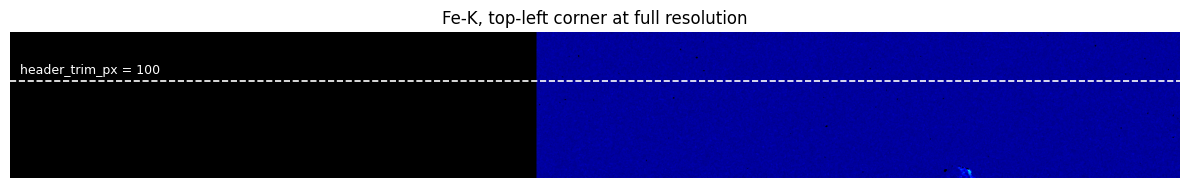

In [4]:
fe_rgb = imageio.imread(DATA_DIR / "NAW 4587-2_S3858-Fe-K.png")
print("full image:", fe_rgb.shape)

crop = fe_rgb[:300, :2400]
fig, ax = plt.subplots(figsize=(12, 2.2))
ax.imshow(crop)
ax.axhline(100, color="white", linestyle="--", linewidth=1.2)
ax.text(20, 92, "header_trim_px = 100", color="white", fontsize=9, va="bottom")
ax.set_title("Fe-K, top-left corner at full resolution")
ax.axis("off")
plt.tight_layout()

## Step 2: colormap inversion, with a round-trip check

With synthetic data we could compare against ground truth. Real data has none, so we check the inversion from the other side, in two parts:

1. **Color round trip.** Invert the RGB image to scalars, render the scalars back through jet, and measure the color difference against the original pixels. This measures how far the export's colors sit from the ideal matplotlib jet palette. Instrument renderers rarely match matplotlib bit for bit, so expect small nonzero differences, not perfection.
2. **Scalar fixed point.** Invert the re-rendered image again and compare scalars. If the nearest-neighbor lookup is doing its job, the scalar values are stable under the round trip even where the colors differ by a few counts. This is the check that matters: the pipeline consumes scalars, not colors.

In [5]:
recovered = invert_colormap(fe_rgb, colormap_spec="cmap:jet")
print("recovered:", recovered.shape, recovered.dtype,
      f"range [{recovered.min():.3f}, {recovered.max():.3f}]")

# Render the recovered scalars back through jet. jet() returns float64
# RGBA, so run the statistics on every 4th pixel to keep memory flat;
# 6.5 million pixels is plenty for a percentile.
jet = matplotlib.colormaps["jet"]
sample_scalar = recovered[100::4, ::4]  # below the header band
roundtrip = (jet(sample_scalar)[..., :3] * 255).astype(np.uint8)
original = fe_rgb[100::4, ::4, :3]

# Black pixels are the no-data marker, not a jet color; skip them.
nonblack = original.any(axis=-1)
color_err = np.abs(roundtrip.astype(int) - original.astype(int)).max(axis=-1)[nonblack]
print(f"\npixels checked: {color_err.size:,} (non-black, below header, 4x strided)")
print("color round trip, max channel difference:")
for p in (50, 90, 99.9):
    print(f"  p{p}: {np.percentile(color_err, p):.0f}/255")

# Scalar fixed point: invert the re-rendered image again
recovered_again = invert_colormap(roundtrip, colormap_spec="cmap:jet")
scalar_drift = np.abs(recovered_again - sample_scalar)
print(f"\nscalar drift after the round trip: max {scalar_drift.max():.4f}")

Loading cached LUT from /home/brendon/Projects/Science/karak/.cache/colormap_full_lut_9f80fbbcb838.npy


recovered: (13050, 7980) float32 range [0.000, 1.000]



pixels checked: 4,424,884 (non-black, below header, 4x strided)
color round trip, max channel difference:
  p50: 2/255
  p90: 6/255
  p99.9: 19/255



scalar drift after the round trip: max 0.0037


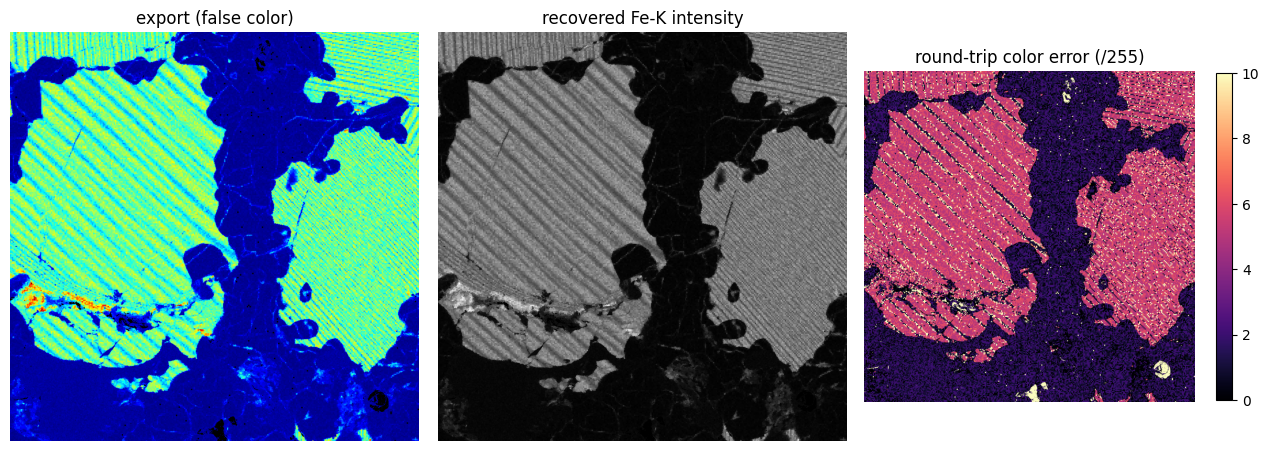

In [6]:
# Visual check on a full-resolution crop from the middle of the section
r0, c0, size = 6000, 3600, 900
crop_rgb = fe_rgb[r0 : r0 + size, c0 : c0 + size, :3]
crop_scalar = recovered[r0 : r0 + size, c0 : c0 + size]
crop_roundtrip = (jet(crop_scalar)[..., :3] * 255).astype(np.uint8)
crop_err = np.abs(crop_roundtrip.astype(int) - crop_rgb.astype(int)).max(axis=-1)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
axes[0].imshow(crop_rgb)
axes[0].set_title("export (false color)")
axes[1].imshow(crop_scalar, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("recovered Fe-K intensity")
im = axes[2].imshow(crop_err, cmap="magma", vmin=0, vmax=10)
axes[2].set_title("round-trip color error (/255)")
fig.colorbar(im, ax=axes[2], shrink=0.8)
for ax in axes:
    ax.axis("off")
plt.tight_layout()

Reading the numbers:

- The color round trip is close but not exact: median difference 2/255, worst case around 19/255. TIMA's jet renderer does not match matplotlib's jet bit for bit, so the export colors sit a few counts off the 4096-entry palette karak samples.
- The scalar fixed point is what the pipeline relies on, and it holds: re-inverting the round-trip image reproduces the scalars to within 0.004. Pixels a few counts off the palette still snap to the same nearest palette entry, which is exactly why the loader uses a nearest-neighbor lookup instead of an exact color match.

The error map in the crop above shows the same thing spatially: differences of a few counts spread over the sample, with no structure that would indicate a wrong palette or a systematic bias. Free the full-resolution arrays before the big load.

In [7]:
del fe_rgb, recovered, roundtrip, original, nonblack, sample_scalar, color_err
del recovered_again, scalar_drift, crop_rgb, crop_scalar, crop_roundtrip, crop_err

## Steps 3 and 4: the full load, as the flow runs it

Now the real thing: run the `load_elements` stage exactly as the `src` node of the publication flow runs it. Every parameter is the stage default, so the only argument is the input directory. The stage discovers the 21 files, inverts 19 element maps, converts SEM to grayscale, downsamples everything 2×, trims 50 rows (100 px at original resolution), and stacks the cube.

Expected geometry: 13050×7980 per image, downsampled to 6525×3990, minus 50 header rows gives 6475×3990. With 19 elements the cube is 6475×3990×19 float32, just under 2 GB. This cell takes a few minutes; the flow engine would cache its output in `{work}/cache/` so later runs skip it, but calling the stage directly like this always does the work.

In [8]:
from karak.stages.load import LoadElementsStage

outputs = LoadElementsStage().run({}, {"input_dir": str(DATA_DIR)})
cube_payload = outputs["cube"]
bse_payload = outputs["bse"]

cube = cube_payload.pixels
bse = bse_payload.pixels
names = list(cube_payload.element_names)
print()
print("cube:", cube.shape, cube.dtype, f"({cube.nbytes / 1e9:.2f} GB)")
print("space tag:", cube_payload.space)
print("elements:", names)

Loaded element 'Al' (inverted via cmap:jet): shape (6475, 3990), range [0.0000, 1.0000]


Loaded element 'Ba' (inverted via cmap:jet): shape (6475, 3990), range [0.0000, 1.0000]


Loaded element 'Ca' (inverted via cmap:jet): shape (6475, 3990), range [0.0000, 1.0000]


Loaded element 'Cl' (inverted via cmap:jet): shape (6475, 3990), range [0.0000, 0.8567]


Loaded element 'Cr' (inverted via cmap:jet): shape (6475, 3990), range [0.0000, 1.0000]


...

Loaded element 'Ti' (inverted via cmap:jet): shape (6475, 3990), range [0.0000, 1.0000]


Loaded element 'Y' (inverted via cmap:jet): shape (6475, 3990), range [0.0000, 1.0000]


Loaded element 'Zn' (inverted via cmap:jet): shape (6475, 3990), range [0.0000, 0.9252]


Loaded 19 element channels + BSE (SEM).  Shape: (6475, 3990)



cube: (6475, 3990, 19) float32 (1.96 GB)
space tag: Space.RAW
elements: ['Al', 'Ba', 'Ca', 'Cl', 'Cr', 'F', 'Fe-K', 'K', 'Mg', 'Mn', 'Na', 'O', 'P', 'S', 'Sb', 'Si', 'Ti', 'Y', 'Zn']


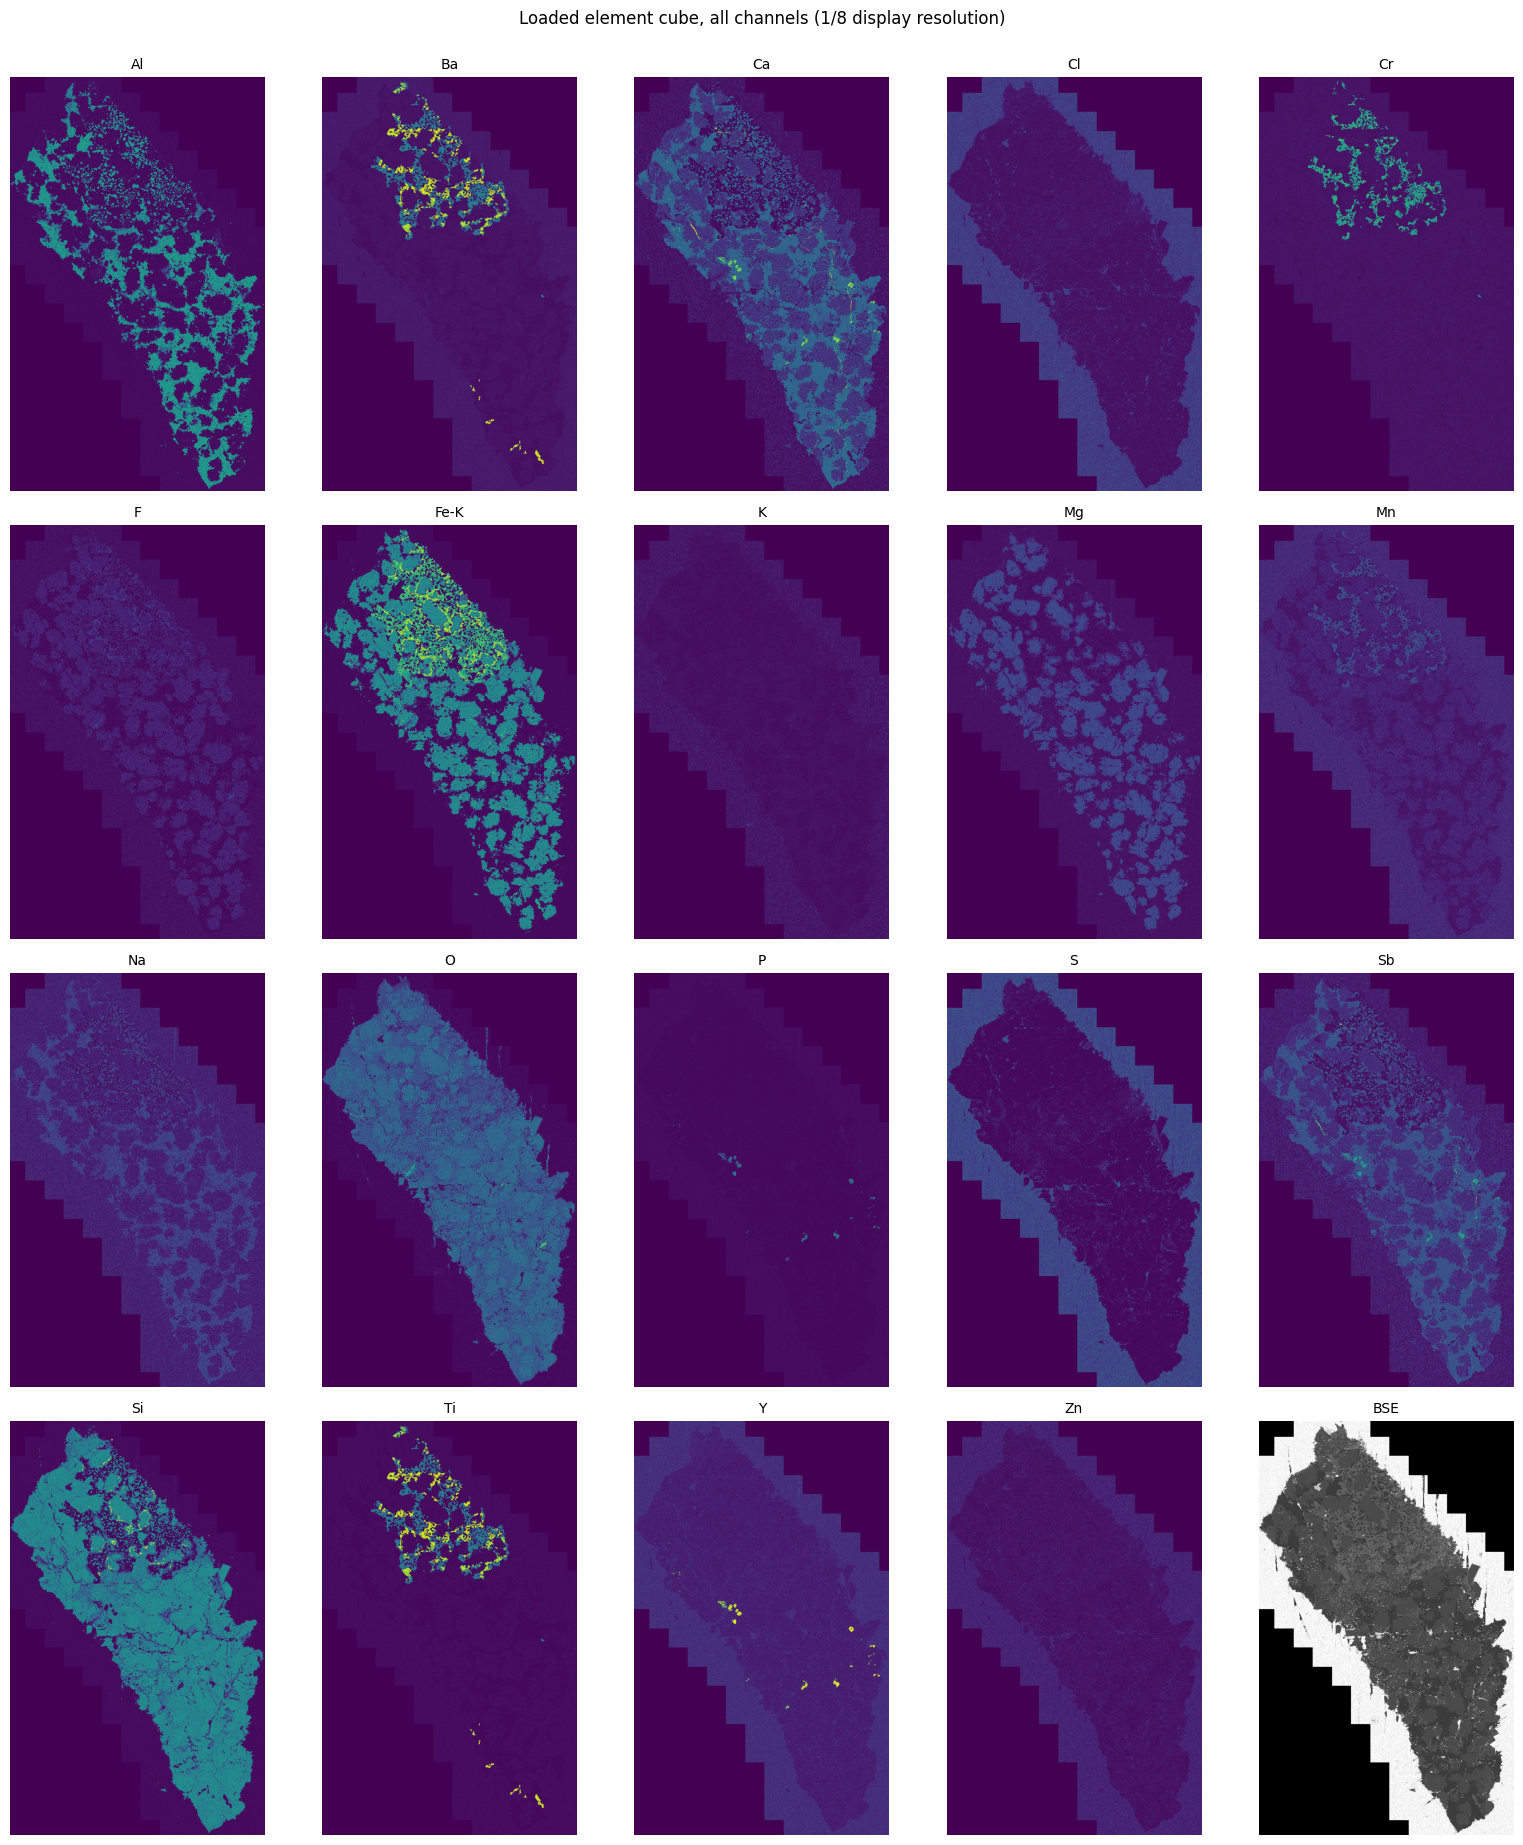

In [9]:
n_panels = len(names) + 1
ncols = 5
nrows = -(-n_panels // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 4.6 * nrows))
for i, (ax, name) in enumerate(zip(axes.ravel(), names)):
    ax.imshow(cube[::8, ::8, i], cmap="viridis", vmin=0, vmax=1)
    ax.set_title(name, fontsize=10)
    ax.axis("off")
axes.ravel()[len(names)].imshow(bse[::8, ::8], cmap="gray", vmin=0, vmax=1)
axes.ravel()[len(names)].set_title("BSE", fontsize=10)
for ax in axes.ravel()[len(names) :]:
    ax.axis("off")
fig.suptitle("Loaded element cube, all channels (1/8 display resolution)", y=1.0)
plt.tight_layout()

## A numeric look at each channel

Per-channel statistics are a quick sanity check before moving on. The zero fraction counts pixels the inversion mapped to exactly 0.0: the black no-data border around the section, plus any pure-black pixels inside it. Every channel shares the same border, so similar zero fractions across channels are expected. Channels with a low mean and a low maximum (the trace elements) carry little signal, which is worth remembering when later stages normalize them.

In [10]:
print(f"{'element':8s} {'min':>6s} {'mean':>7s} {'max':>6s} {'zero %':>7s}")
for i, name in enumerate(names):
    ch = cube[..., i]
    zero_pct = 100 * (ch == 0).mean()
    print(
        f"{name:8s} {ch.min():6.3f} {ch.mean():7.4f} "
        f"{ch.max():6.3f} {zero_pct:6.1f}%"
    )
print(f"{'BSE':8s} {bse.min():6.3f} {bse.mean():7.4f} {bse.max():6.3f}")

element     min    mean    max  zero %


Al        0.000  0.0930  1.000   31.4%


Ba        0.000  0.0588  1.000   31.3%


Ca        0.000  0.1051  1.000   31.3%
Cl        0.000  0.0682  0.857   31.4%


Cr        0.000  0.0495  1.000   31.4%
F         0.000  0.0412  0.718   32.1%


...

S         0.000  0.0694  0.904   31.4%


Sb        0.000  0.0943  1.000   31.3%


Si        0.000  0.1750  1.000   31.3%
Ti        0.000  0.0409  1.000   31.4%


Y         0.000  0.0722  1.000   31.3%


Zn        0.000  0.0481  0.925   32.0%
BSE       0.000  0.3674  1.000


That completes the load stage on the publication sample: a 6475×3990×19 raw cube plus a BSE image, identical to what the flow's `src` node hands to the next stage.

From the command line the equivalent full run is:

```bash
karak run --builtin tiled --input "/home/brendon/Dropbox/Projects/izawa/NWA4587_LPSC26/data" --out output/nwa4587
```

The next node is `mask`, which separates sample from epoxy and applies the hand-drawn valid-area mask stored in `data/mask/Valid_mask.csv`. That is where tutorial 3 picks up.